In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [3]:
# Let's rename all the files first:

rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)
NList = [4,6,8,10]

for prob in probList:
    for N in NList:
        if os.path.isfile("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
            os.rename("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
            os.rename("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
                   
N=4
for rate in rateList:
        
    if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out"):
        os.rename("RC_raw/S_Z/S1_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out",
                 "RC_raw/S_Z/S1_S_Z_p=0.0_r=" + str(rate) + "_N=" + str(N) + ".out")

In [4]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,21).round(2)
NList = [4,6,8,10]

t_total = 400
dt=5
steps = int(t_total/dt)

avgedMI_dynamics_0 = {}
avgedMI_steady_0 = {}

for rate in rateList:
    avgedMI_dynamics_0[rate] = {}
    avgedMI_steady_0[rate] = {}

    for prob in probList: 
        avgedMI_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") ).astype(float)        
                steps = temp.shape[1]//5
                
                avgedMI_dynamics_0[rate][prob] = np.average(temp,axis=0)                
                avgedMI_steady_0[rate][prob][n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])
                #if n==2:
                #    print('rate', rate, 'prob', prob, 'ss MI',avgedMI_steady_0[rate][prob][n])
            
            else:
                #print("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out")
                print('missing rate=',rate,',prob=', prob,'N=',N)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 1.0 ,prob= 0.05 N= 10
missing rate= 1.0 ,prob= 0.15 N= 10
missing rate= 10.0 ,prob= 0.05 N= 10
missing rate= 100.0 ,prob= 0.05 N= 10
missing rate= 1000.0 ,prob= 0.15 N= 6
missing rate= 1000.0 ,prob= 0.6 N= 8
missing rate= 1000.0 ,prob= 0.6 N= 10


Text(0.5, 1.0, 'dissipation rate = 1000.0')

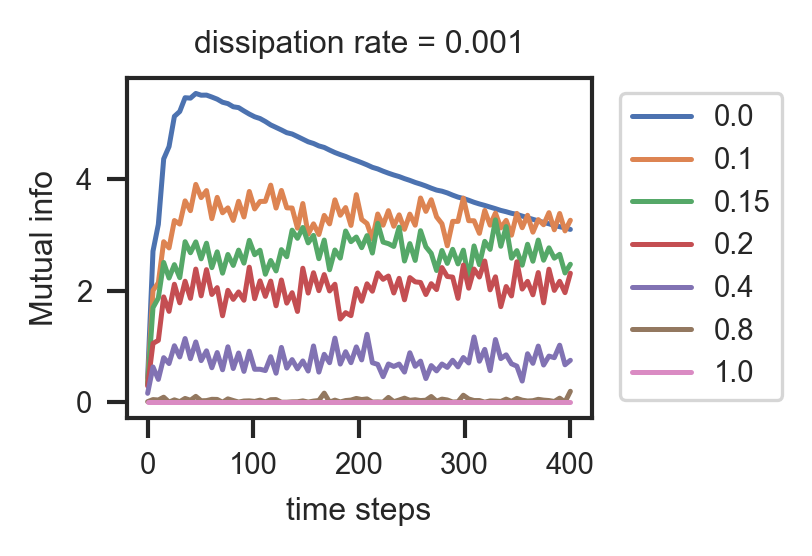

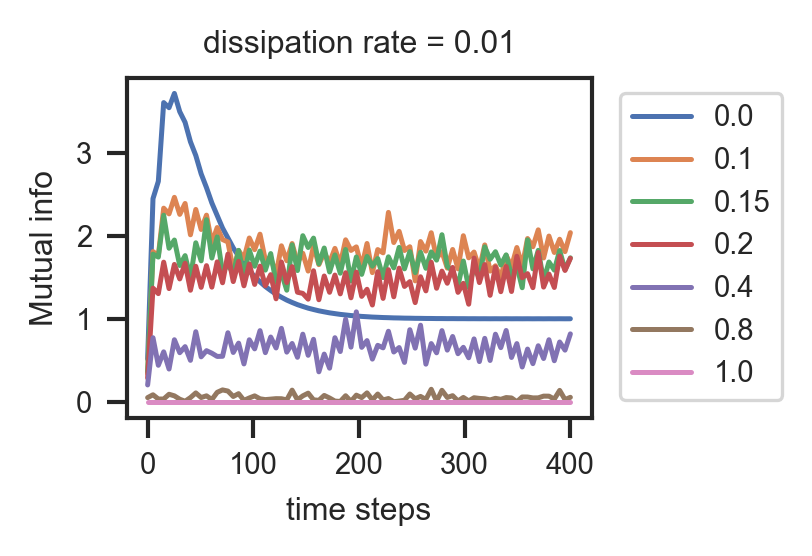

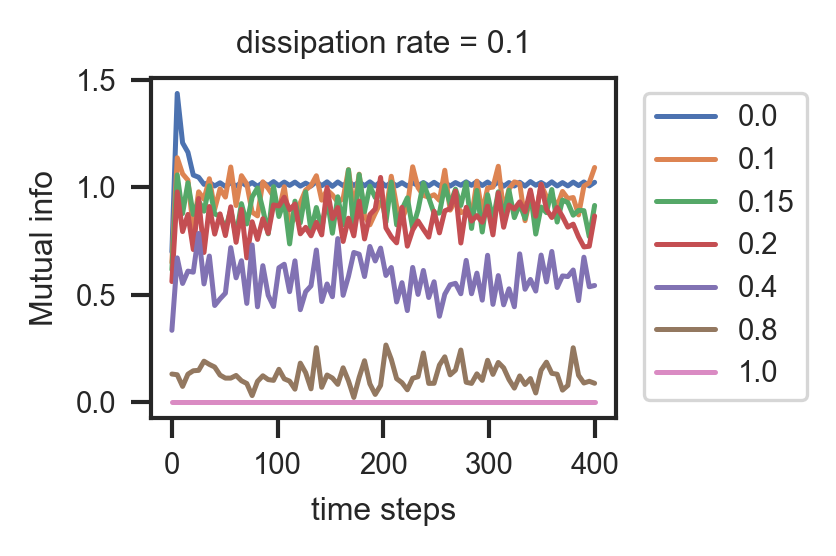

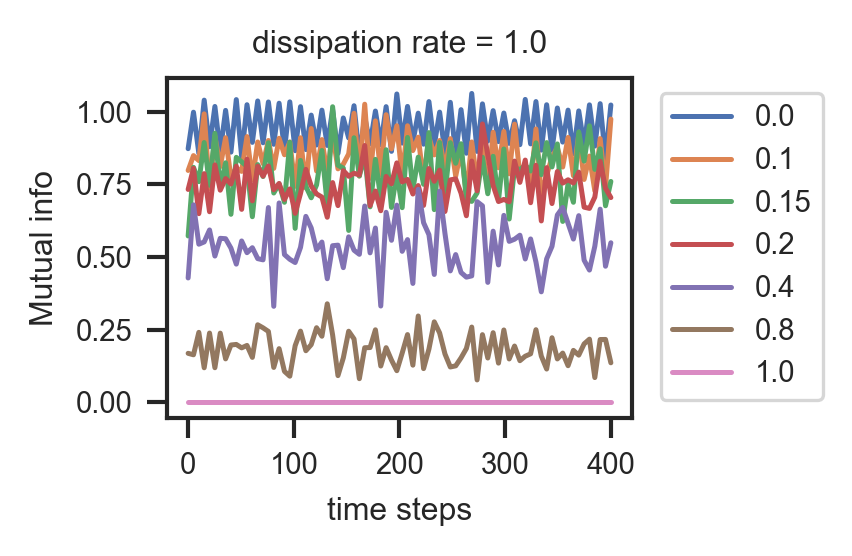

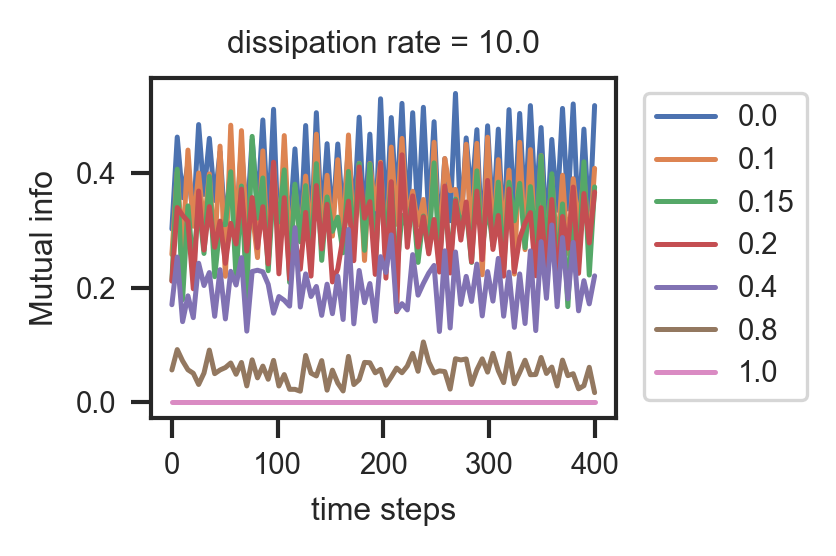

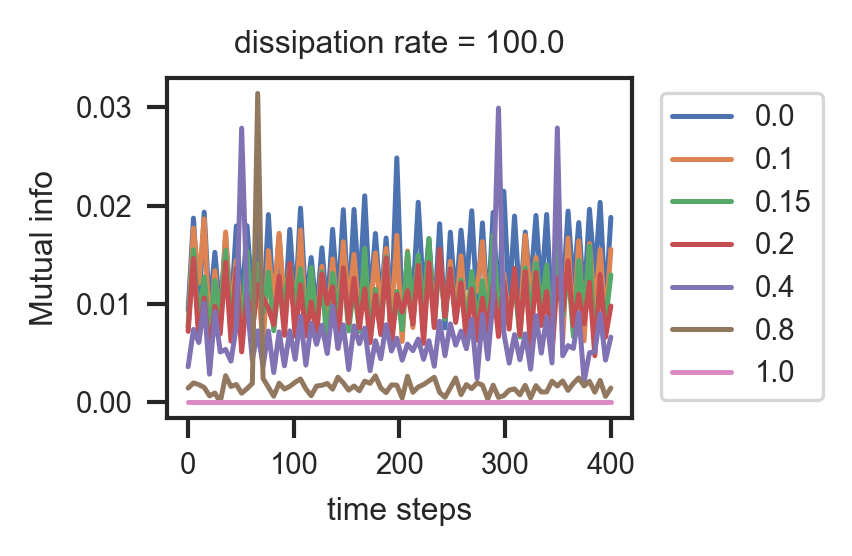

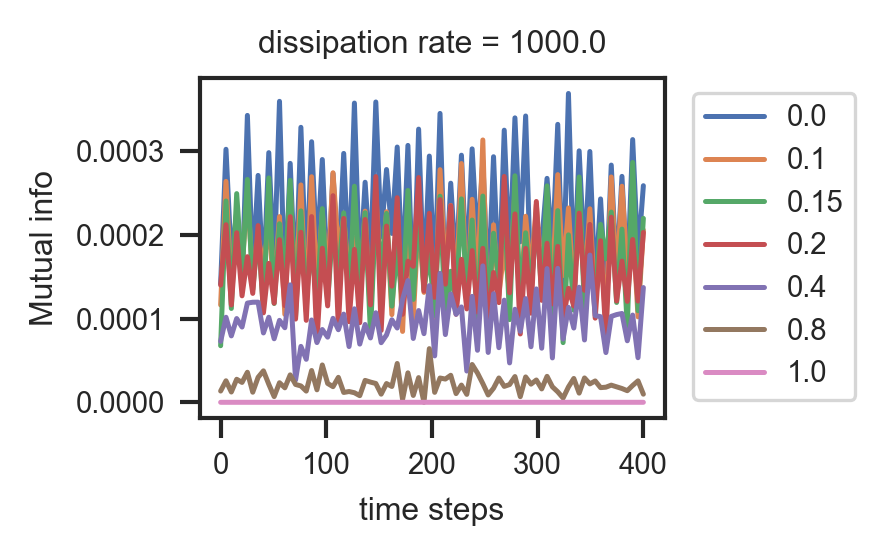

In [7]:
rateList = [1e-5, 1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0, 0.1, 0.15, 0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))


probTempList = [0.0, 0.1, 0.15, 0.2, 0.4, 0.8, 1.0]
plt.figure()
rate =0.01
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))

plt.figure()
rate =0.1
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))

plt.figure()
rate =1.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))


probTempList = [0.0, 0.1, 0.15, 0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 10.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))

plt.figure()
rate = 100.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))


plt.figure()
rate = 1000.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dissipation rate = ' + str(rate))



In [23]:
rateList=[0.001, 0.1, 1.0, 10.0,1000.0]

Text(0.5, 1.0, 'msm prob=0.3, $\\sigma_-$, N=10')

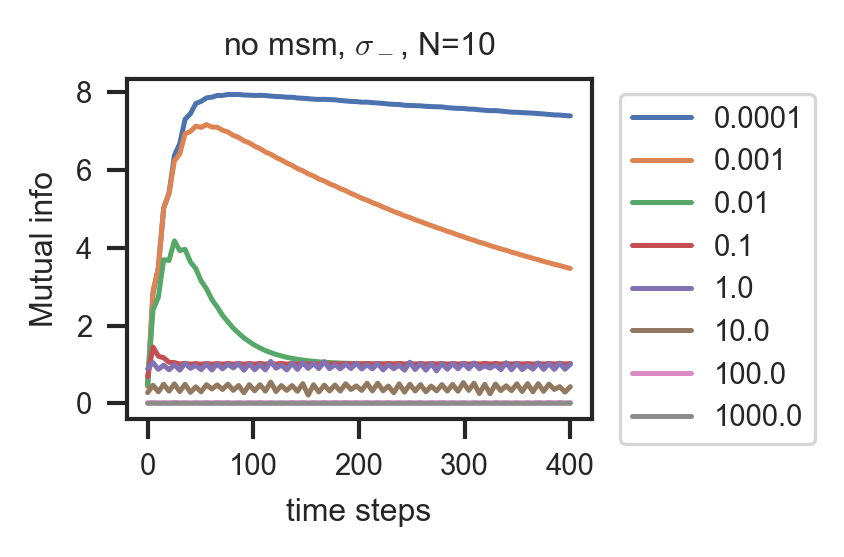

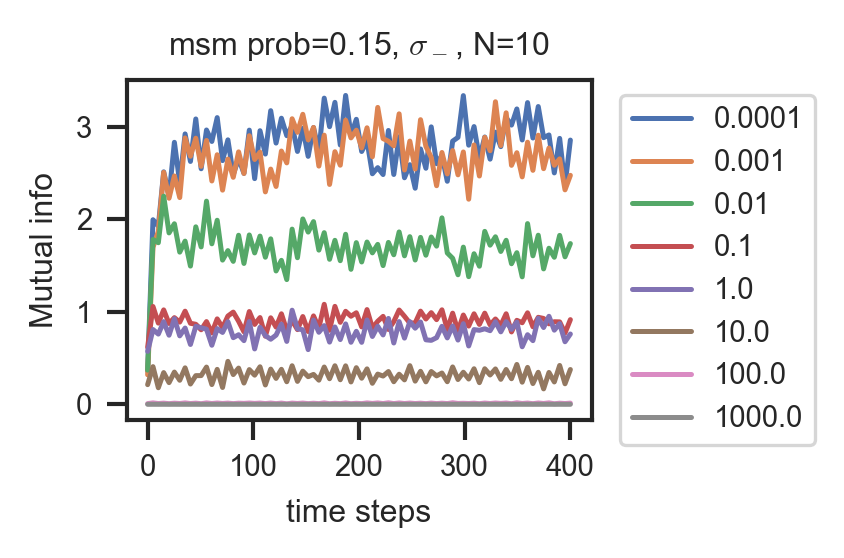

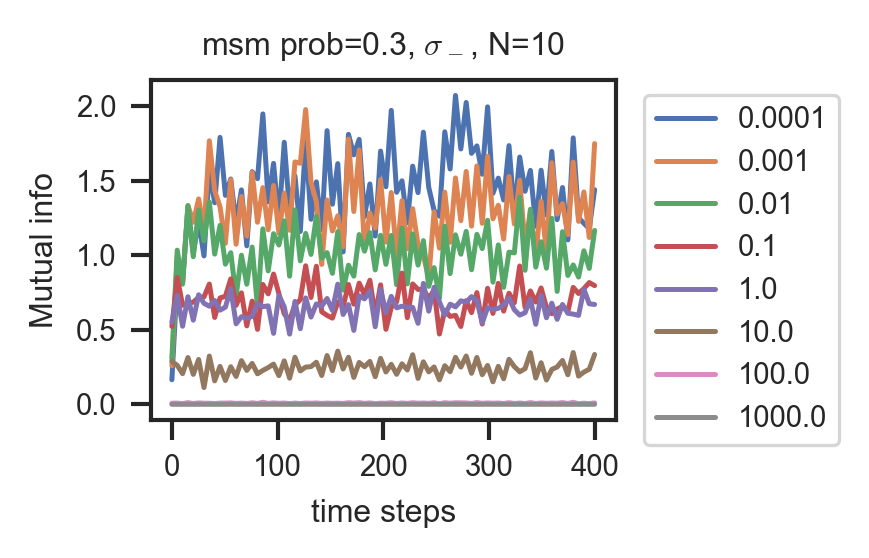

In [21]:
plt.figure()
prob=0.0
for rate in rateList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')
        
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('no msm, $\sigma_-$, N=10')


plt.figure()
prob=0.15
for rate in rateList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')
        
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('msm prob='+str(prob)+', $\sigma_-$, N=10')

plt.figure()
prob=0.3
for rate in rateList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')
        
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('msm prob='+str(prob)+', $\sigma_-$, N=10')


In [44]:
int(t_total/dt)

80

[7.46033882e+00 3.75390600e+00 1.00499600e+00 1.01515052e+00
 9.45787171e-01 3.91184386e-01 1.36451812e-02 2.22535671e-04]
[4.52565839e+00 3.86816205e+00 1.92537883e+00 9.42162943e-01
 8.35464961e-01 3.49012031e-01 1.22634083e-02 1.93499230e-04]
[2.44140370e+00 2.28193970e+00 1.49380492e+00 8.38271726e-01
 7.16338509e-01 2.99028375e-01 1.00399192e-02 1.62587417e-04]
[1.39624118e+00 1.31176094e+00 1.02926524e+00 7.23926045e-01
 6.40764323e-01 2.48439718e-01 7.95847148e-03 1.21338217e-04]
[8.44656636e-01 7.70593462e-01 6.95675655e-01 5.71082861e-01
 5.36137841e-01 2.16268558e-01 6.48007386e-03 1.03068736e-04]
[0.22361908 0.21133491 0.23906798 0.31570627 0.33908285 0.12992426
 0.00322284 0.        ]
[3.45245924e-02 4.91853682e-02 3.82864238e-02 1.39987633e-01
 1.75550792e-01 5.86649498e-02 1.52186001e-03 2.15088863e-05]
[-1.21129565e-15 -1.76188458e-16  7.57476892e-17 -1.77189528e-16
 -5.16452417e-15  1.63992079e-14  2.20790749e-11  1.30425841e-08]


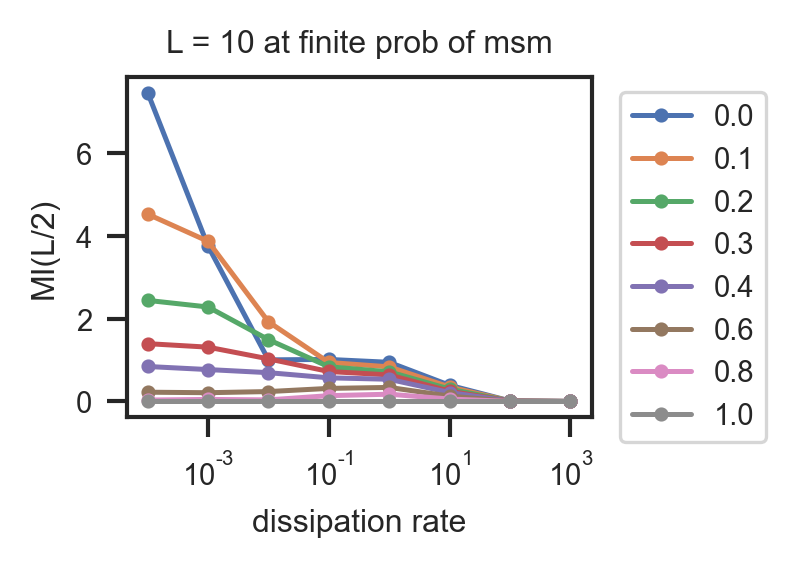

In [8]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, .8, 1.0]
rateTempList = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0,1000.0]

plt.figure()
for prob in probTempList:
    MIinRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        MIinRate[r] = avgedMI_steady_0[rate][prob][3]
    print(MIinRate)
    plt.semilogx(np.array(rateTempList).astype(float), MIinRate,'.-')
    plt.xlabel('dissipation rate')
    plt.ylabel('MI(L/2)')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



In [25]:
avgedMI_steady_0[0.001]

{0.0: array([1.75656536, 2.6195775 , 3.21514765, 3.63484893]),
 0.1: array([1.57395978, 2.51679928, 3.22052092, 3.89673055]),
 0.2: array([1.16948509, 1.62063839, 2.10758158, 2.23689996]),
 0.3: array([0.71742841, 0.98680923, 1.2755111 , 1.35496951]),
 0.4: array([0.56072043, 0.62602987, 0.77053778, 0.77569387]),
 0.5: array([0.36908441, 0.39683798, 0.45554373, 0.49140782]),
 0.6: array([0.16397978, 0.24496003, 0.23305028, 0.24452702]),
 0.7: array([0.07086433, 0.11985689, 0.08832244, 0.05315337]),
 0.8: array([0.04518872, 0.05602903, 0.05062113, 0.05518589]),
 0.9: array([0.00427421, 0.01343235, 0.00535675, 0.01866003]),
 1.0: array([-7.79874182e-15, -5.22569627e-14, -4.94726511e-14, -2.66952209e-18])}

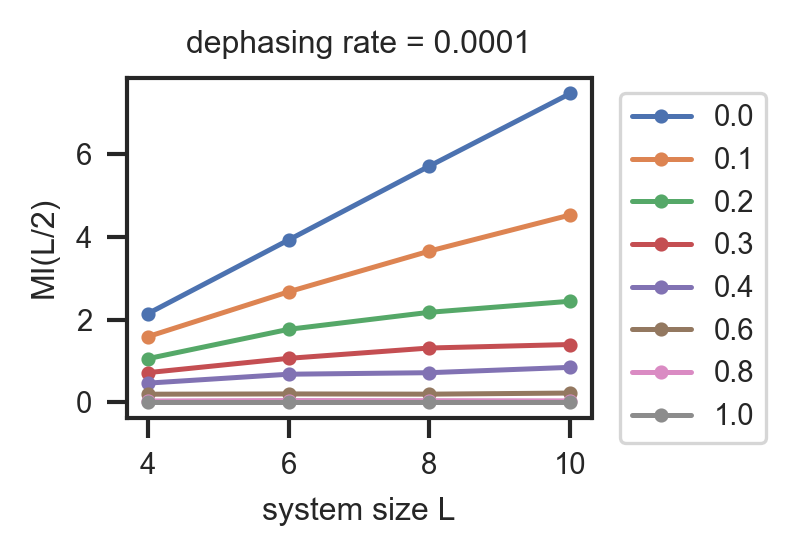

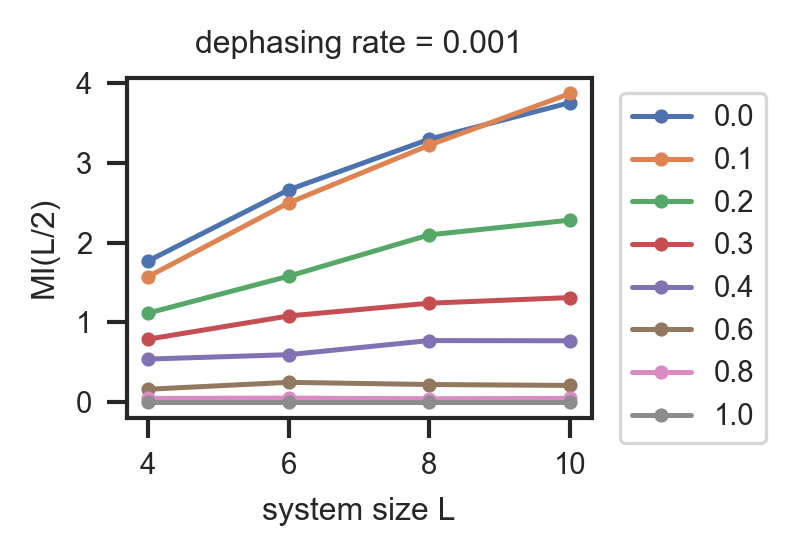

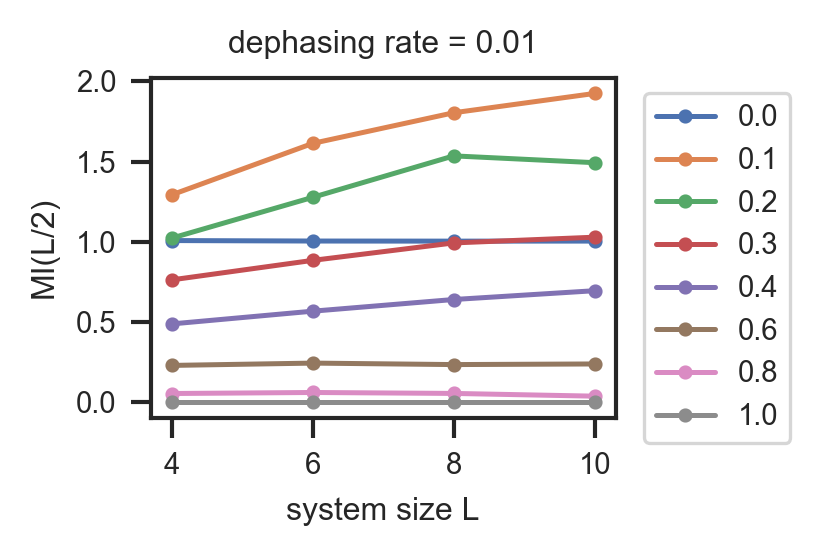

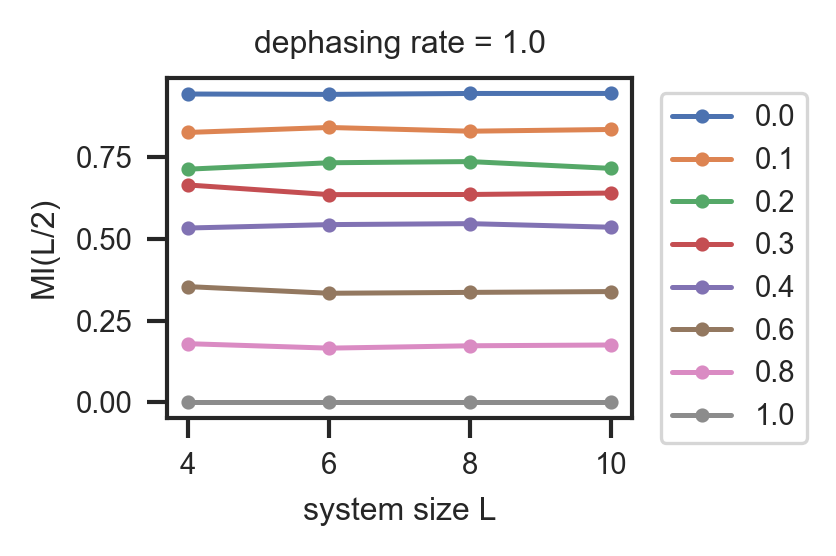

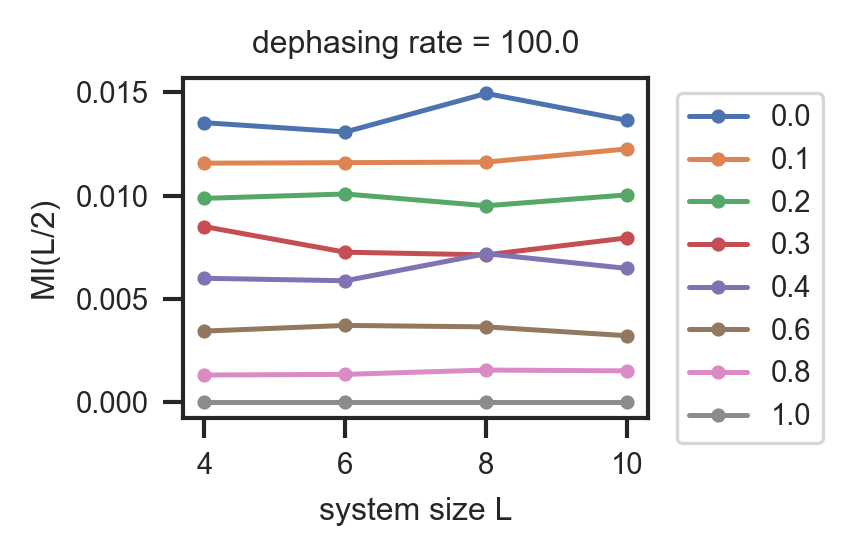

In [9]:
rateTempList = [0.0001,0.001, 0.01, 1.0,100.0]

for rate in rateTempList:
    plt.figure()
    for prob in probTempList:
        plt.plot(np.array(NList), avgedMI_steady_0[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('MI(L/2)')
        plt.title('dephasing rate = ' + str(rate))
    plt.legend(probTempList,bbox_to_anchor= (1.03, 1))


In [35]:
avgedStot_dynamics_0 = {}
avgedStot_steady_0 = {}

for rate in rateList:
    avgedStot_dynamics_0[rate] = {}
    avgedStot_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedStot_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedStot_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedStot_steady_0[rate][prob][n] = np.average(temp[-10:])
        #else:
            #print('missing rate=',rate,', prob=', prob)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



Text(0.5, 1.0, 'dephasing rate = 1000.0')

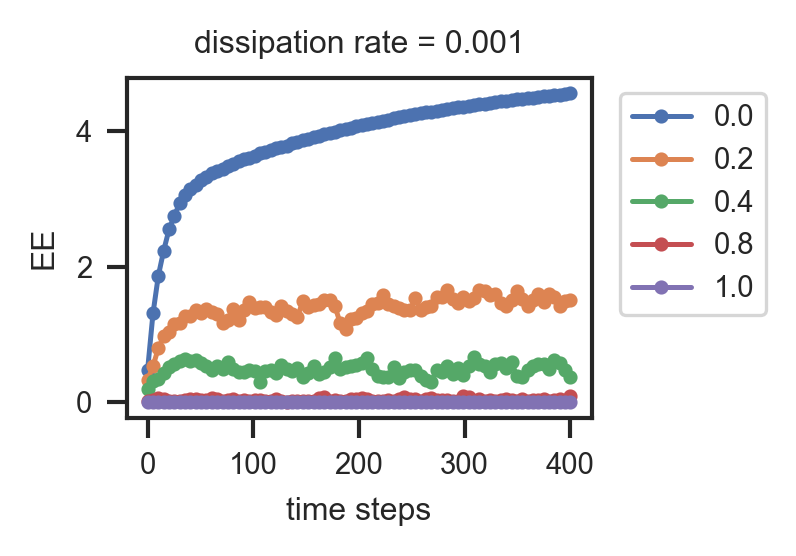

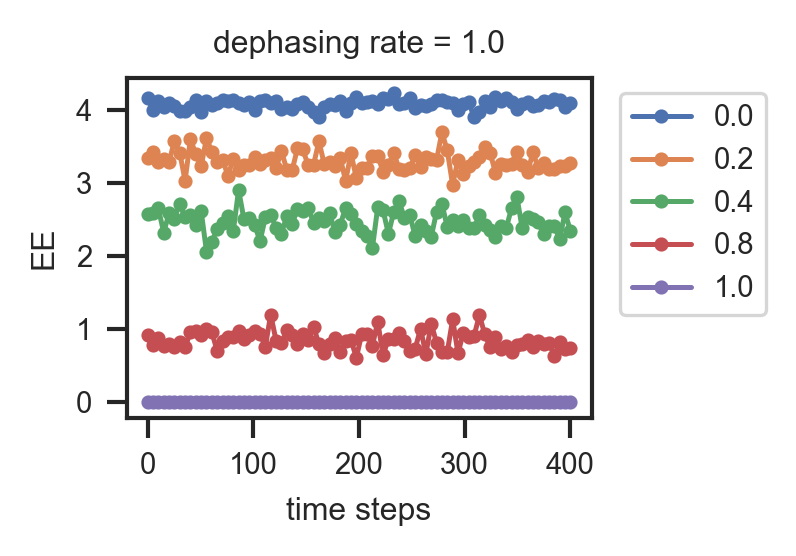

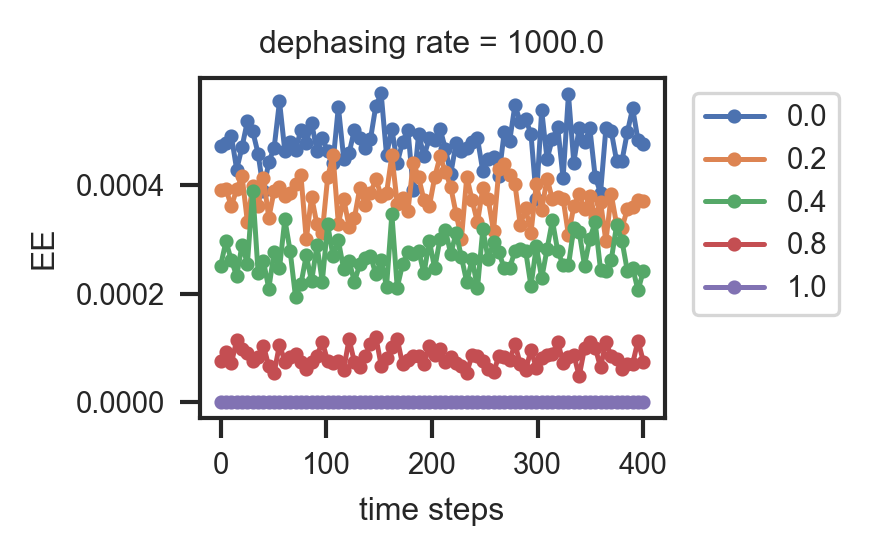

In [36]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dissipation rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('EE')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('EE')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1000.0
for prob in probTempList: 
    N=8
    if os.path.isfile("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('EE')
plt.title('dephasing rate = ' + str(rate))



In [160]:
avgedStot_dynamics_0 = {}
avgedStot_steady_0 = {}

for rate in rateList:
    avgedStot_dynamics_0[rate] = {}
    avgedStot_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/S_minus/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/S_minus/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedStot_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedStot_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedStot_steady_0[rate][prob][n] = np.average(temp[-10:])
        #else:
            #print('missing rate=',rate,', prob=', prob)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



Text(0, 0.5, 'total S')

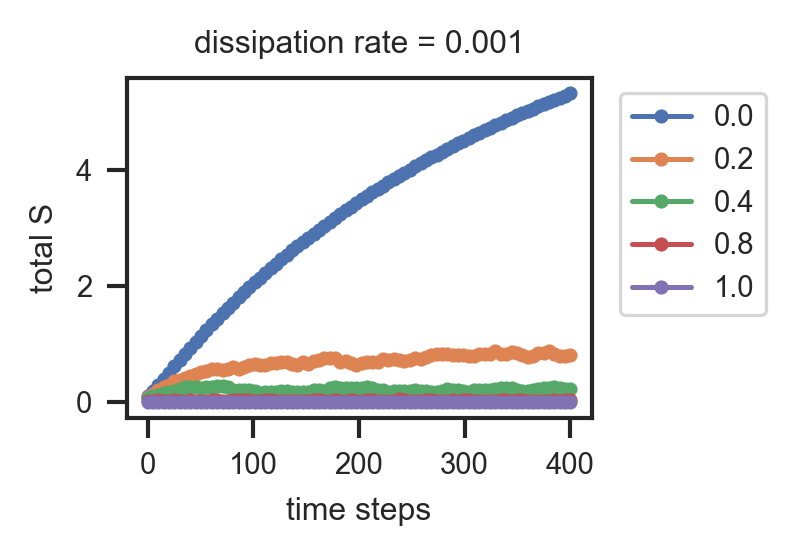

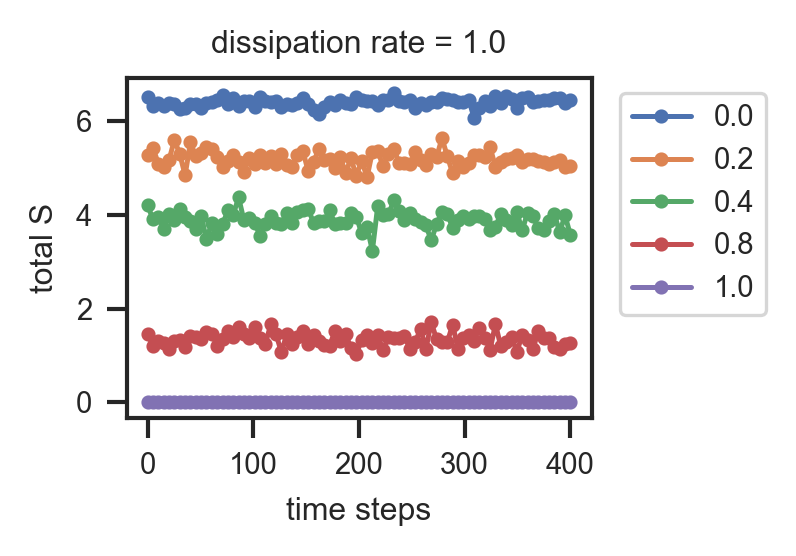

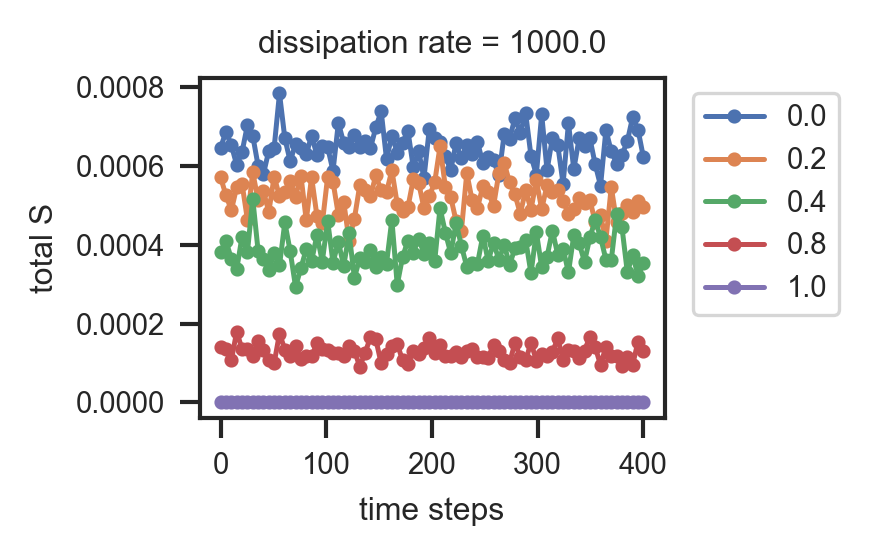

In [161]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dissipation rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('total S')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dissipation rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('total S')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1000.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/Stot_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dissipation rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('total S')



In [30]:
test1 = [i for i in range(10)]
print(test1[:-4])
print(test1[-4:])

[0, 1, 2, 3, 4, 5]
[6, 7, 8, 9]


In [162]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)
NList = [4,6,8,10]

t_total = 400
dt=5
steps = int(t_total/dt)

avgedP_dynamics_0 = {}
avgedP_steady_0 = {}

for rate in rateList:
    avgedP_dynamics_0[rate] = {}
    avgedP_steady_0[rate] = {}

    for prob in probList: 
        avgedP_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedP_dynamics_0[rate][prob] = np.average(temp,axis=0)
                
                steps = len(temp)//2

                avgedP_steady_0[rate][prob][n] = np.average(temp[-10:])
            
            #"S1_S_minus_p=0.75_r=0.01_N=10.out"
            else:
                print('missing rate=',rate,',prob=', prob,'N=',N)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 1000.0 ,prob= 0.6 N= 8
missing rate= 1000.0 ,prob= 0.6 N= 10


[0.90631105 0.43181326 0.0488966  0.00347361 0.00985409 0.46410824
 0.99151257 0.99991539]
[0.97622484 0.78835615 0.27432309 0.02462422 0.0284494  0.52484722
 0.9930209  0.99993132]
[0.99421434 0.94230962 0.60377346 0.11767296 0.0758596  0.60778122
 0.99477546 0.99994969]
[0.99931621 0.99245108 0.93643329 0.62006108 0.43663718 0.84167418
 0.99830871 0.99998253]
[1.         1.         1.         1.         1.         1.
 1.         0.99999999]


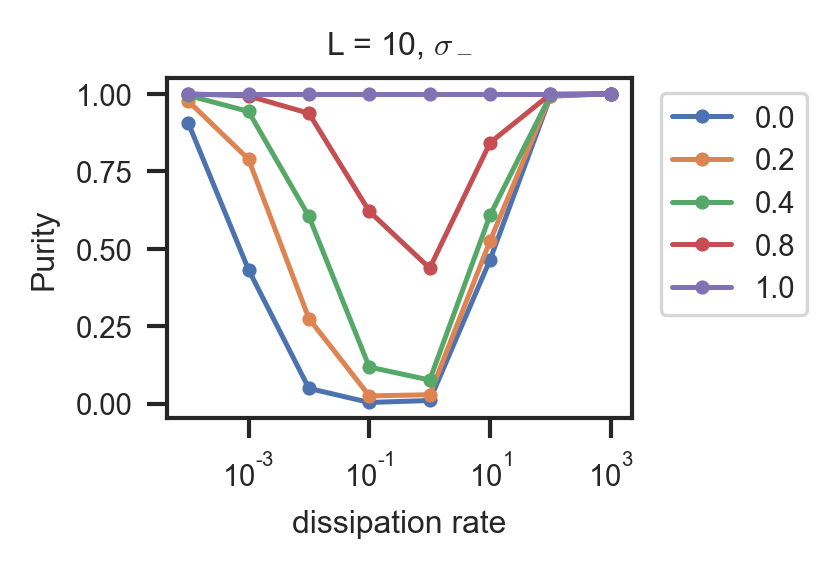

In [164]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.0, 0.2, 0.4, .8, 1.0]
rateTempList = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0,1000.0]


plt.figure()
for prob in probTempList:
    purityInRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        purityInRate[r] = avgedP_steady_0[rate][prob][3]
    print(purityInRate)
    plt.semilogx(np.array(rateTempList).astype(float), purityInRate,'.-')
    plt.xlabel('dissipation rate')
    plt.ylabel('Purity')
plt.title('L = 10, $\sigma_-$')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



In [165]:
avgedS1_dynamics_0 = {}
avgedS1_steady_0 = {}

for rate in rateList:
    avgedS1_dynamics_0[rate] = {}
    avgedS1_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedS1_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedS1_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedS1_steady_0[rate][prob][n] = np.average(temp[-10:])


[-3.69194905e-16 -3.12934727e-16  4.54085707e-16 -2.81152731e-14
  4.74007015e-15  5.87248142e-15  2.37732267e-12  7.16035059e-09]
[-3.69194905e-16 -3.12934727e-16  4.54085707e-16 -2.81152731e-14
  4.74007015e-15  5.87248142e-15  2.37732267e-12  7.16035059e-09]
[-3.69194905e-16 -3.12934727e-16  4.54085707e-16 -2.81152731e-14
  4.74007015e-15  5.87248142e-15  2.37732267e-12  7.16035059e-09]
[-3.69194905e-16 -3.12934727e-16  4.54085707e-16 -2.81152731e-14
  4.74007015e-15  5.87248142e-15  2.37732267e-12  7.16035059e-09]
[-3.69194905e-16 -3.12934727e-16  4.54085707e-16 -2.81152731e-14
  4.74007015e-15  5.87248142e-15  2.37732267e-12  7.16035059e-09]


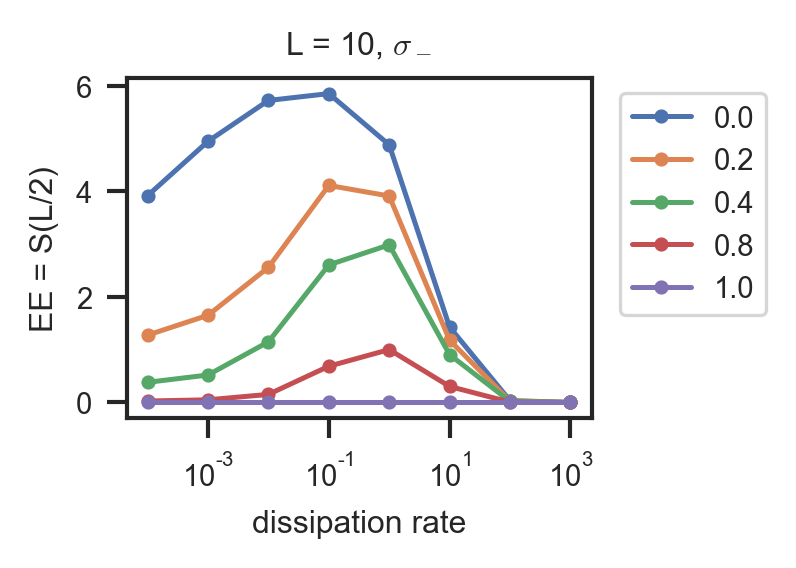

In [169]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.0, 0.2, 0.4, .8, 1.0]
rateTempList = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0,1000.0]


plt.figure()
for prob in probTempList:
    S1InRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        S1InRate[r] = avgedS1_steady_0[rate][prob][3]
    print(purityInRate)
    plt.semilogx(np.array(rateTempList).astype(float), S1InRate,'.-')
    plt.xlabel('dissipation rate')
    plt.ylabel('EE = S(L/2)')
plt.title('L = 10, $\sigma_-$')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



Text(0, 0.5, 'purity')

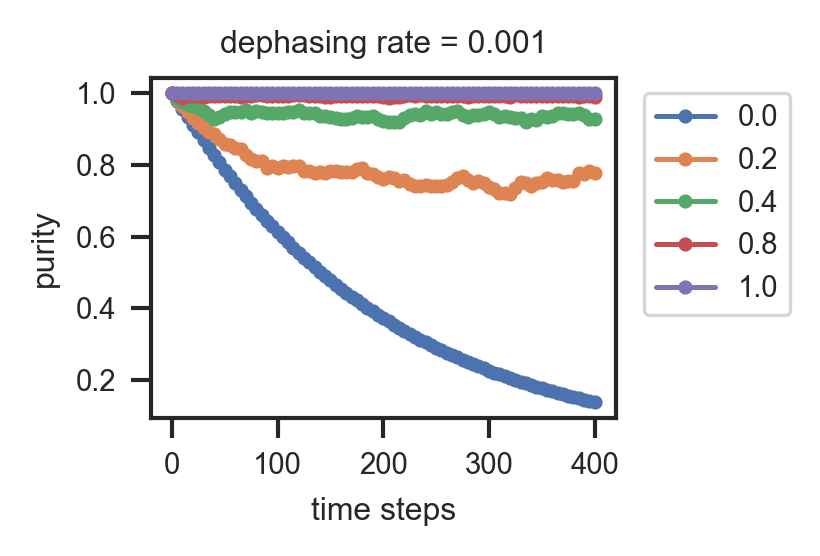

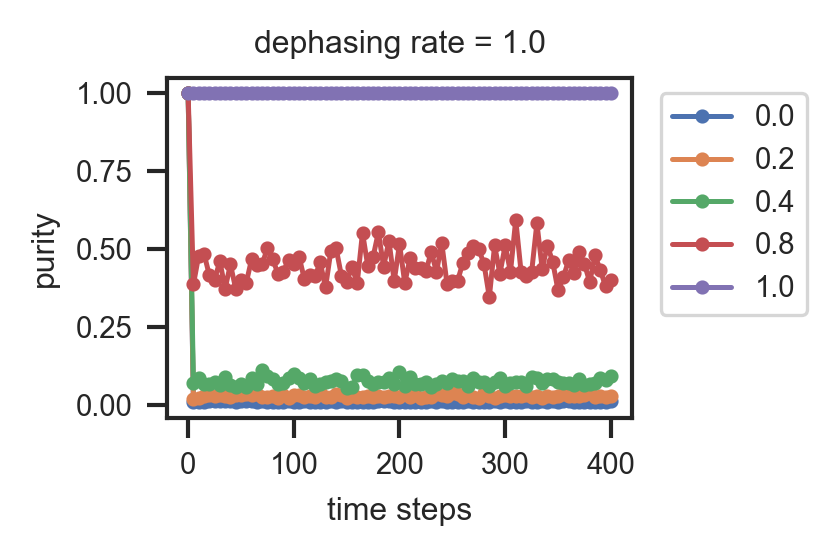

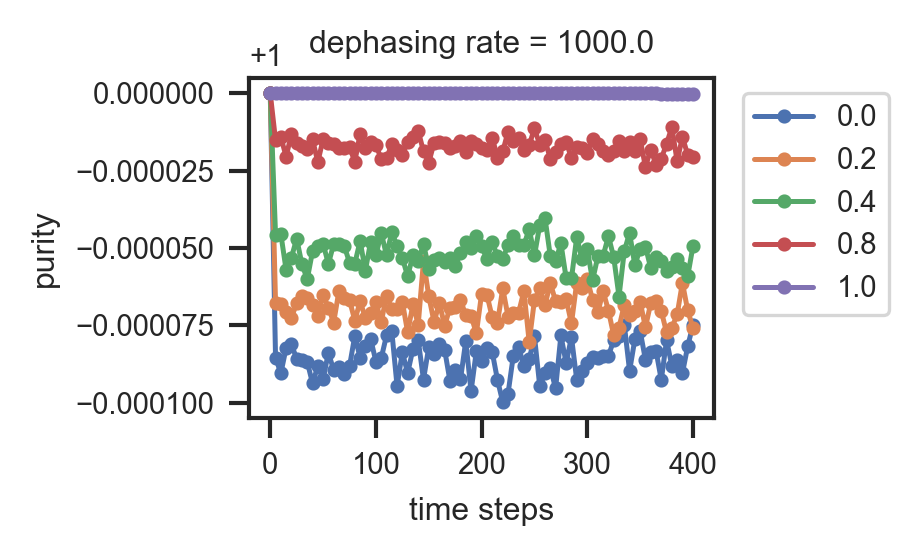

In [149]:
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt)+1)

probTempList = [0.0,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.concatenate([np.array([1]), np.average(temp,axis=0)]),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('purity')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1.0
for prob in probTempList: 
    N=10
    if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.concatenate([np.array([1]), np.average(temp,axis=0)]),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('purity')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1000.0
for prob in probTempList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.concatenate([np.array([1]), np.average(temp,axis=0)]),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('purity')



Text(0, 0.5, 'purity')

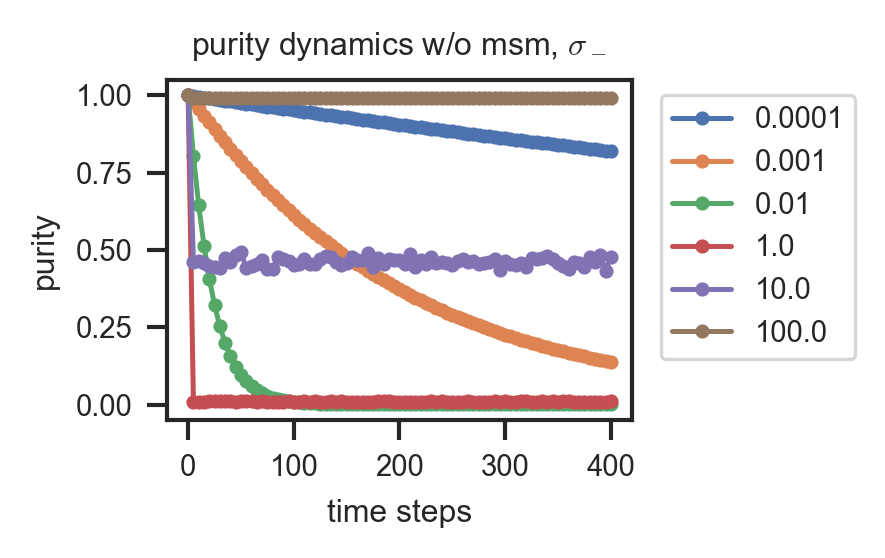

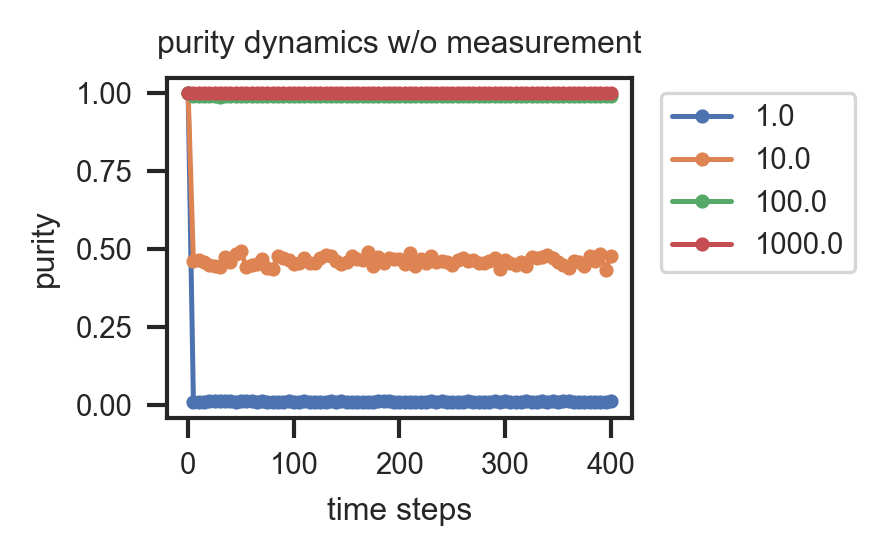

In [152]:
prob=0.0
rateList = [1e-4,1e-3,1e-2,1e0,1e1,1e2]

duration = np.linspace(0,t_total,int(t_total/dt)+1)

for rate in rateList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.concatenate([np.array([1]), np.average(temp,axis=0)]),'.-')

plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.title('purity dynamics w/o msm, $\sigma_-$')
plt.xlabel('time steps')
plt.ylabel('purity')

plt.figure()
rateList = np.logspace(0,3,4)
for rate in rateList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.concatenate([np.array([1]), np.average(temp,axis=0)]),'.-')

plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.title('purity dynamics w/o measurement')
plt.xlabel('time steps')
plt.ylabel('purity')



In [103]:
from scipy import optimize

decay rate= 0.00041181500573842883 prefactor = 1.1890197624342222 offset =  -0.18901976243422225
decay rate= 0.004816734918056909 prefactor = 1.0115822298893578 offset =  -0.011582229889357754
decay rate= 0.04560662143565913 prefactor = 0.9998635898056151 offset =  0.0001364101943849283
decay rate= 0.38794640505555655 prefactor = 0.9986905184265408 offset =  0.0013094815734592258


Text(0, 0.5, 'purity')

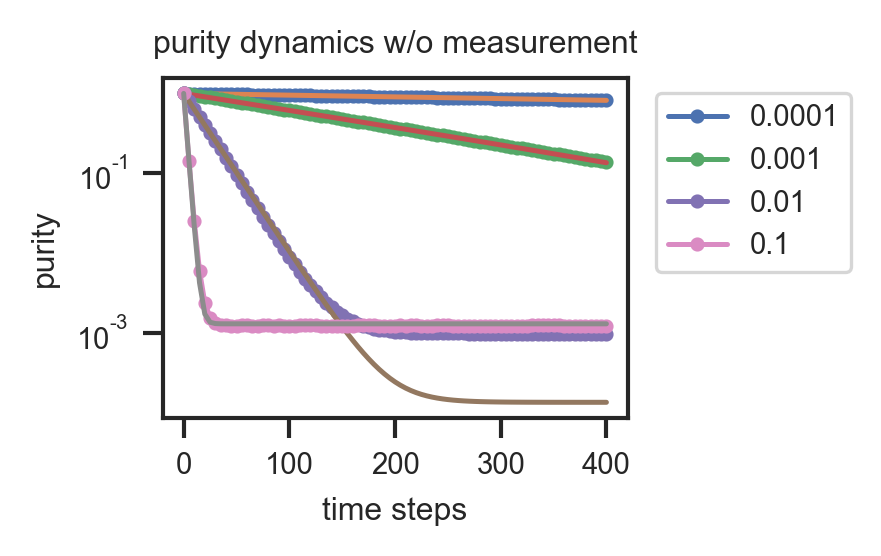

In [121]:
# Let's fit some exponential decay to purity of the state for small Gamma values
def monoExp(x, m, t):
    return m * np.exp(-t * x) + (1-m)

prob=0.0
rateList = np.logspace(-4,-1,4)

duration = np.linspace(0,t_total,int(t_total/dt)+1)

for rate in rateList: 

    N=10
    if os.path.isfile("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.semilogy(duration, np.concatenate([ np.array([1]), np.average(temp,axis=0)]),'.-')
        
        p0 = (1, 0.01)
        
        params, cv = optimize.curve_fit(monoExp, duration, np.concatenate([ np.array([1]), np.average(temp,axis=0)]), p0)
        m, t = params
        
        print("decay rate=", t, "prefactor =", m, "offset = ", 1-m)
        plt.semilogy(duration, m*np.exp(-t*duration)+(1-m), label = '_nolegend_')

plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.title('purity dynamics w/o measurement')
plt.xlabel('time steps')
plt.ylabel('purity')

In [122]:
0.0013094815734592258-0.0001364101943849283

0.0011730713790742975

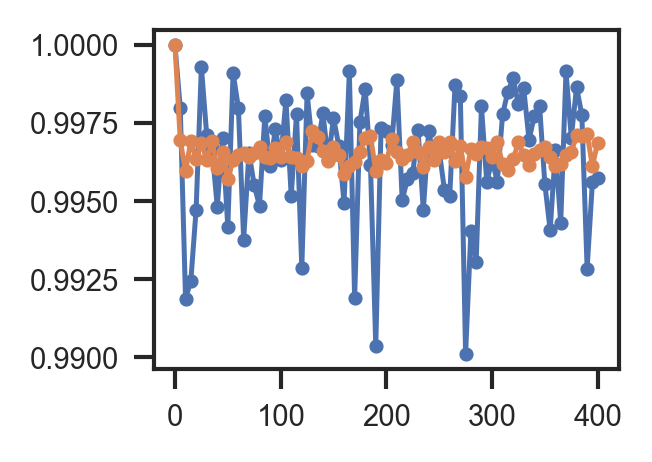

In [138]:
prob = 0.0
rate = 100.0
N
temp = np.array(np.loadtxt("RC_raw/S_minus/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(4) + ".out") )         
#print(np.average(temp,axis=0).shape)
for i in range(1):
    plt.plot(duration, np.concatenate([ np.array([1]), temp[i,:]]),'.-')
    
plt.plot(duration,np.concatenate([ np.array([1]), np.average(temp,axis=0)]),'.-')

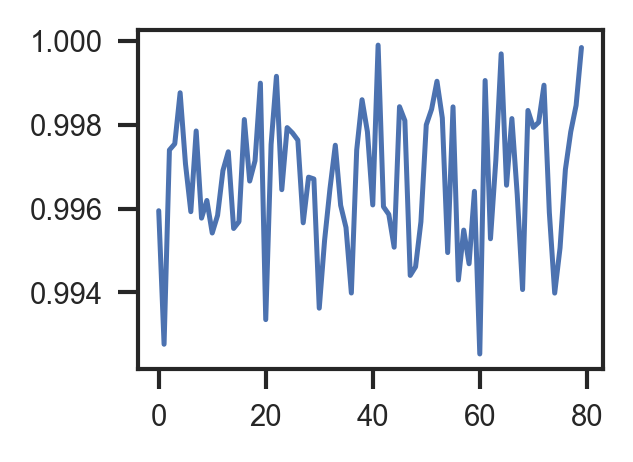

In [144]:
temp = np.array(np.loadtxt("../../Downloads/purity_S_minus_p=0_r=100_N=4.out") )         
plt.plot(temp)

In [130]:
from scipy import linalg, sparse

def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q
    return q

In [132]:
[evals,evecs]=linalg.eigh(mkU(4))

In [136]:
abs(evals)
for i in range(4):
    for j in range(i):
        print(evecs[:,i]@evecs[:,j].conj())

(-1.3053794156725473e-16+8.326672684688674e-17j)
(-1.6653345369377348e-16+1.942890293094024e-16j)
(7.494005416219807e-16+2.7755575615628914e-16j)
(3.5735303605122226e-16+3.608224830031759e-16j)
(4.163336342344337e-16-3.0531133177191805e-16j)
(4.2327252813834093e-16+2.7755575615628914e-17j)
